In [1]:
import numpy as np, pandas as pd
from tools.core import *
from tools.clustering import *

from scipy.spatial.distance import pdist, squareform

import matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns

sns.set_palette('colorblind')
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize":6, "ytick.labelsize":6, 'legend.fontsize':6, "legend.title_fontsize":7})
plt.rcParams['svg.fonttype'] = 'none'
cm = 1/2.54  # centimeters in inches

In [2]:
def classical_MDS(D, n_components=2, tol=1e-12):
    """
    Classical MDS (Torgerson) from distance matrix D.
    - D: (n,n) numpy array of pairwise distances (finite)
    - n_components: target dimension
    Returns X: (n, n_components) embedding
    """
    n = D.shape[0]
    D2 = D ** 2

    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J.dot(D2).dot(J)
    B = (B + B.T) / 2.0

    # eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # keep positive eigenvalues above tol
    positive = eigvals > tol
    if not np.any(positive):
        # all nonpositive: return zeros
        return np.zeros((n, n_components))
    L = np.sqrt(np.maximum(eigvals[positive], 0.0))
    V = eigvecs[:, positive]
    X_full = V * L[np.newaxis, :]   # each column scaled by sqrt(eig)
    if X_full.shape[1] >= n_components:
        X = X_full[:, :n_components]
    else:
        # pad with zeros if fewer positive eigenvalues
        pad = np.zeros((n, n_components - X_full.shape[1]))
        X = np.hstack([X_full, pad])
    return X

In [3]:
df_abund = pd.read_csv("data/rutor_glacier/Abund.csv", index_col=0)
df_traits = pd.read_csv("data/rutor_glacier/Traits.csv", index_col=0).iloc[:, :6]
df_traits = df_traits.apply(lambda x: (x-x.mean())/x.std())

ground_truth = np.array([0]*17 + [1]*32 + [2]*10) # Early / Mid / Late stage

$\mathbf{Z}$ is positive definite

In [4]:
emb = df_traits.to_numpy()
D = squareform( pdist(emb, metric='euclidean') )

Z = 1.0 - D/D.max()
np.linalg.eigvalsh(Z).min()

0.06645297536338188

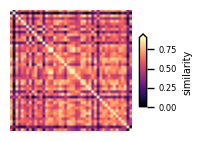

In [7]:
fig, ax = plt.subplots(1,1,figsize=(16/3*cm, 4*cm))

plt.colorbar(
    ax.imshow(Z, vmin=0, vmax=np.tril(Z, -1).max(), cmap='magma'), ax=ax, label='similarity', shrink=0.6, extend='max', aspect=10
)
ax.set_axis_off()

In [5]:
arr_vectors = np.asarray(df_abund.to_numpy(), dtype=float)
arr_vectors /= arr_vectors.sum(axis=1)[:, np.newaxis]

The region of strict concavity for $\alpha=3$ contains all the vectors

In [6]:
np.array([is_CND(get_hessian(Z, 3, p)) for p in arr_vectors])

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

## Visualising the inter-plot similarities

In [10]:
def pairwise_jbd_slow(P: np.ndarray, Z: np.ndarray, alpha: float) -> np.ndarray:
    """
    Condensed pairwise JB distances for rows of P with Z
    Returns 1D condensed array like scipy.spatial.distance.pdist.
    """
    P = np.asarray(P, dtype=float)
    M, N = P.shape
    assert Z.shape == (N, N)

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty(0, dtype=float)

    out = np.empty(L, dtype=float)
    idx = 0
    for i in range(M - 1):
        a = P[i]
        for j in range(i + 1, M):
            b = P[j]
            out[idx] = get_entropy(Z, alpha, (a+b)/2) - 0.5*(get_entropy(Z, alpha, a) + get_entropy(Z, alpha, b))
            idx += 1
    return out

(0.07748965105000366, -0.048831316489987564)

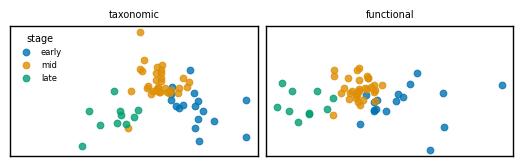

In [11]:
fig, axes = plt.subplots(1,2, figsize=(13*cm, 4*cm), layout='constrained', sharey=True, )

ax = axes[0]
for i in [0,1,2]:
    ax.scatter(
        *classical_MDS(
            squareform( pairwise_jbd_slow(P=arr_vectors, Z=np.eye(45), alpha=2) )
        )[ground_truth==i].T,
        alpha=0.8,
        label = ['early', 'mid', 'late'][i],
        marker='o'
    )
ax.set_title('taxonomic')
ax.set_aspect('equal')
ax.set_xticks([])
ax.legend(title='stage', frameon=False, loc='upper left')


ax = axes[1]
for i in [0,1,2]:
    ax.scatter(
        *classical_MDS(
            squareform( pairwise_jbd_slow(P=arr_vectors, Z=Z, alpha=2) )
        )[ground_truth==i].T,
        alpha=0.8,
        label = ['early', 'mid', 'late'][i],
        marker='o'
    )

ax.set_aspect('equal')
#ax.set_axis_off()
ax.set_title('functional')
ax.set_xticks([])
ax.set_yticks([])

axes[0].set_xlim(ax.get_xlim()[::-1])

# Compute taxonomic and functional $\beta$-diversity

In [7]:
dict_total = {
    'taxonomic': {2: get_bregman_information(np.eye(45), 2, arr_vectors / 59.), 3: get_bregman_information(np.eye(45), 3, arr_vectors / 59.)},
    'functional': {2: get_bregman_information(Z, 2, arr_vectors / 59.), 3: get_bregman_information(Z, 3, arr_vectors / 59.)}
}

dict_obs = {
    'taxonomic': {a: np.array([get_bregman_information(np.eye(45), a, arr_vectors[ground_truth==i]/(ground_truth==i).sum() ) for i in [0,1,2]]) / dict_total['taxonomic'][a] for a in [2,3]},
    'functional': {a: np.array([get_bregman_information(Z, a, arr_vectors[ground_truth==i]/(ground_truth==i).sum() ) for i in [0,1,2]]) / dict_total['functional'][a] for a in [2,3]}
}

In [8]:
dict_expl = {
    t: {a: 1. - np.sum(dict_obs[t][a] * np.array([17, 32, 10.]) / 59. ) for a in [2, 3]} for t in dict_total
}

## Null model

In [9]:
null_explained = {'taxonomic': {2: [], 3:[]}, 'functional': {2: [], 3:[]}}
null_vectors = arr_vectors.copy()

rng = np.random.default_rng(42)
for _ in range(1000):
    rng.shuffle(null_vectors)

    for a in [2,3]:
        resid = np.array([get_bregman_information( np.eye(45), a, null_vectors[ground_truth==i]/(ground_truth==i).sum() ) for i in [0,1,2]]) / dict_total['taxonomic'][a]
        null_explained['taxonomic'][a].append(1. - (resid * np.array([17, 32, 10.]) / 59.).sum())

        resid = np.array([get_bregman_information( Z, a, null_vectors[ground_truth==i]/(ground_truth==i).sum() ) for i in [0,1,2]]) / dict_total['functional'][a]
        null_explained['functional'][a].append(1. - (resid * np.array([17, 32, 10.]) / 59.).sum())

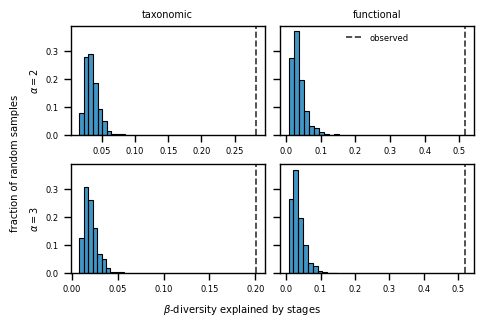

In [15]:
fig, axes = plt.subplots(2,2,figsize=(12*cm, 8*cm), layout='constrained', sharey=True, )


for idx, a in enumerate([2,3]):
    ax = axes[idx][0]
    sns.histplot( 
        null_explained['taxonomic'][a],
        ax = ax,
        stat = 'probability',
        bins = 10
    )
    ax.set_ylabel(r'$\alpha=$' + str(a))
    ax.axvline(dict_expl['taxonomic'][a], ls='--', label='observed', c='black', alpha=.8)

    if idx == 0:
        ax.set_title('taxonomic')

    ax = axes[idx][1]
    sns.histplot( 
        null_explained['functional'][a],
        ax = ax,
        stat = 'probability', 
        bins = 10
    )
    ax.axvline(dict_expl['functional'][a], ls='--', label='observed', c='black', alpha=.8)

    if idx==0:
        ax.legend(frameon=False, loc='upper center')
        ax.set_title('functional')

    fig.supxlabel(r'$\beta$' + "-diversity explained by stages")
    fig.supylabel("fraction of random samples")

In [11]:
dict_Z = {'taxonomic': np.eye(45), 'functional': Z}

## Replicating Fig. 4

In [12]:
a = 2 # pick alpha

null_early = {'taxonomic': [], 'functional': []}
null_mid = {'taxonomic': [], 'functional': []}
null_late = {'taxonomic': [], 'functional': []}

null_vectors = arr_vectors.copy()

rng = np.random.default_rng(42)
for _ in range(1000):
    rng.shuffle(null_vectors)
    for zname in dict_Z:
        resid = np.array([get_bregman_information( dict_Z[zname], a, null_vectors[ground_truth==i]/(ground_truth==i).sum() ) for i in [0,1,2]]) / dict_total[zname][a]
        null_early[zname].append(resid[0])
        null_mid[zname].append(resid[1])
        null_late[zname].append(resid[2])

null_data = [null_early, null_mid, null_late]

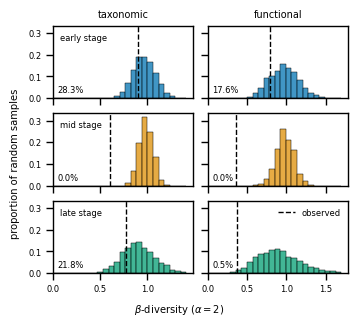

In [ ]:
fig, axes = plt.subplots(3,2,figsize=(8.8*cm, 8*cm), layout='constrained', sharex='col', sharey=True)

for idx, zname in enumerate(dict_Z):
    bins = np.linspace(0, max([max(nd[zname]) for nd in null_data]), 25) 

    for stage, txt in enumerate(['early stage', 'mid stage', 'late stage']):
        sns.histplot(
            null_data[stage][zname],
            ax = axes[stage, idx],
            color = sns.color_palette()[stage],
            bins = bins,
            stat = 'proportion',
        )
        axes[stage, idx].axvline(dict_obs[zname][a][stage], ls='--', lw=1, color='black', label='observed')
        axes[stage, idx].set_xlim(0, None)
        axes[stage, idx].set_ylabel('')
        
        if idx == 0:
            fig.text(.05,.90, txt, transform=axes[stage, 0].transAxes, ha='left', va='top')      
        
        pval = np.round( ( np.array(null_data[stage][zname]) <= dict_obs[zname][a][stage] ).sum() * 100. / len(null_data[stage][zname]), 2)
        fig.text(.03, .05, f"{pval}%", transform=axes[stage, idx].transAxes, ha='left', va='bottom')

    axes[0,idx].set_title(zname)

axes[2, 1].legend(frameon=False, loc='upper right')
fig.supxlabel(r'$\beta$-diversity ($\alpha=$' + f'{a})')
fig.supylabel('proportion of random samples')